In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

In [5]:
def dj_query(num_qubits):
    # Create a circuit implementing for a query gate for a random function
    # satisfying the promise for the Deutsch-Jozsa problem.
 
    qc = QuantumCircuit(num_qubits + 1)
 
    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc
 
    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )
 
    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc
 
    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")
 
    qc.barrier()
 
    return qc

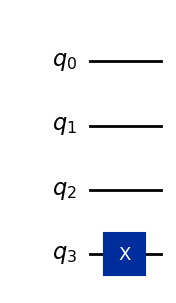

In [6]:
display(dj_query(3).draw(output="mpl"))

In [7]:
def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa algorithm.
 
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(function, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

In [8]:
def dj_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.
 
    qc = compile_circuit(function)
 
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

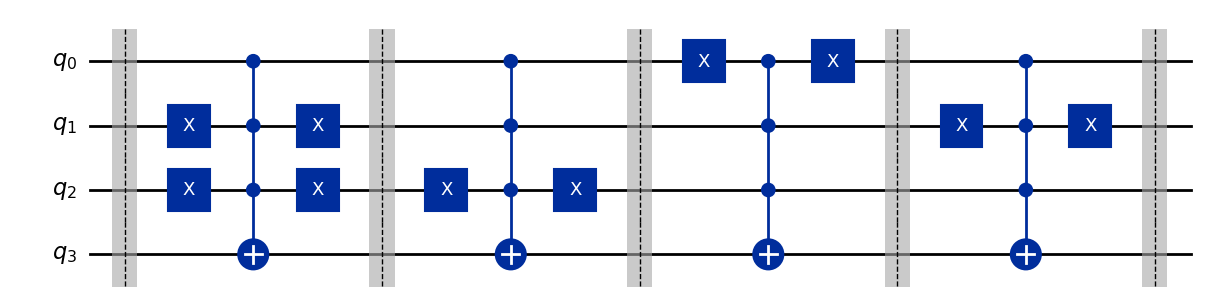

'balanced'

In [12]:
f = dj_query(3)
display(f.draw("mpl"))
display(dj_algorithm(f))

## DJ algo implementation

In [13]:
from qiskit import * 
from qiskit.visualization import plot_histogram
import numpy as np

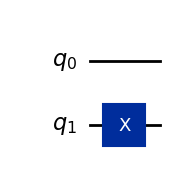

In [14]:
### create a constant oracle , input has no effect on the output
# create a quantum circuit with 2 qubits. One as input , one as output
constant_oracle=QuantumCircuit(2)
#get a random number from 0 and 1
output=np.random.randint(2)

# whatever get in input , it's having no effect . 
# the output will be the random value 0 or 1
if output==1:
    constant_oracle.x(1)
    
# draw the circuit
constant_oracle.draw('mpl')

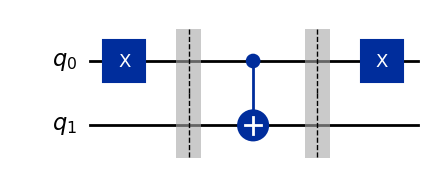

In [15]:
# create a balanced oracle
# perform CNOts with ffirst qubit input as control and second qubit output as the target
balanced_oracle=QuantumCircuit(2)
# place x gate for input qubit
balanced_oracle.x(0)
#use barrier as divider
balanced_oracle.barrier()
#place controlled-cnot gates
balanced_oracle.cx(0,1)
#using bariier as a divider & avoid cancelling gates by the transpiler
balanced_oracle.barrier()
# place x gates
balanced_oracle.x(0)
# show oracle
balanced_oracle.draw("mpl")

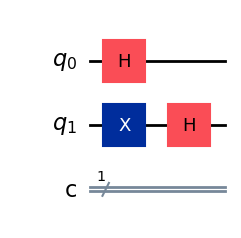

In [16]:
## initialize the input qubits in the state |+>
# and the output qubit in the state |->
dj_circuit=QuantumCircuit(2,1) # 2qbubit with measurememnt at 1 st qubit
# apply H gates
dj_circuit.h(0)
#put qubit in the state |->
dj_circuit.x(1)
dj_circuit.h(1)
dj_circuit.draw("mpl")

In [19]:
oracle_fn=constant_oracle
#oracle_fn=balanced_oracle
# add oracle function
dj_circuit += oracle_fn
dj_circuit.draw("mpl")

TypeError: unsupported operand type(s) for +=: 'QuantumCircuit' and 'QuantumCircuit'

In [ ]:
# perform H-gates on qubit & measure input register
dj_circuit.h(qubit)
dj_circuit.barrier()

# measure
dj_circuit.measure(0,0)

# display circuit
dj_circuit.draw('mpl')

In [ ]:
# check the output
# use local simulator
backend=BasicAer.get_backend("qasm_simulator")
shots=1024
results=execute(dj_circuit, backend=backend, shots=shots).result()
plot_histogram(answer)

In [ ]:
import cv2

# Open the default webcam
cap = cv2.VideoCapture(0)





In [ ]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Display the resulting frame
    cv2.imshow('Webcam Feed', frame)

    # Press 'q' to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the capture and close windows
cap.release()
cv2.destroyAllWindows()
